In [1]:
# !pip install keras-cv==0.6.1 keras-core==0.1.0 tensorflow==2.13.1 tensorflow-datasets==4.9.7

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import optimizers
import keras_cv
import numpy as np
from keras_cv import bounding_box
import os
from keras_cv import visualization
import tqdm
import json

In [3]:
path_to_downloaded_file = keras.utils.get_file(
    origin="https://archive.org/download/self-driving-car.v-3-fixed-small.coco/Self%20Driving%20Car.v3-fixed-small.coco.zip",
    extract=True,
)

In [4]:
path_to_downloaded_file

'C:\\Users\\lma\\.keras\\datasets\\Self%20Driving%20Car.v3-fixed-small.coco.zip'

In [5]:
# !unzip path_to_downloaded_file -d .

################################################
# Manually extracted the zip file to get the following files:
# ./SelfDrivingCar.v3-fixed-small.coco

In [6]:
!ls

10-Pretrained_Classifier.ipynb
11-Fine_Tune_Classifier.ipynb
12-Pretrained_Object_Detection.ipynb
21-Train_Object_Detection_Simple-failed.ipynb
22-Train_Object_Detection_Custom_Dataset-failed.ipynb
30-Stable_Diffusion_1.ipynb
30-Stable_Diffusion_2.ipynb
30-Stable_Diffusion_3_(Mixed_Precision_+_JIT).ipynb
SelfDrivingCar.v3-fixed-small.coco
images
lions_cheetahs.zip


In [7]:
!ls SelfDrivingCar.v3-fixed-small.coco/export

1478019952686311006_jpg.rf.54e2d12dbabc46be3c78995b6eaf3fee.jpg
1478019952686311006_jpg.rf.JLSB3LP2Q4RuGHYKqfF6.jpg
1478019953180167674_jpg.rf.8a816c9d7e9b423a63ed6ecd4a663e47.jpg
1478019953180167674_jpg.rf.azslsZnM8FLQPu3QWLTl.jpg
1478019953689774621_jpg.rf.2e4b7ae29c3379da1282e85cff4c1745.jpg
1478019953689774621_jpg.rf.UpOkvtBppZZaLfvVZ0JX.jpg
1478019954186238236_jpg.rf.cbpP963e2sN7rHIZMJtD.jpg
1478019954186238236_jpg.rf.f8ac6ad31e400d4918ff394f903bb95c.jpg
1478019954685370994_jpg.rf.049fda8ca86adf1e404b41955eb4aba8.jpg
1478019954685370994_jpg.rf.Jah8pEPis5n1x6iQCtmT.jpg
1478019955185244088_jpg.rf.gJpj2eCO1Dd7Sic9WlhE.jpg
1478019955679801306_jpg.rf.QnW1eAO23mmDm9ap1gm7.jpg
1478019955679801306_jpg.rf.e0c1afab5b4a00d9812e56907cd1b9bf.jpg
1478019956186247611_jpg.rf.9ad113e7eb74453890500935ec00590a.jpg
1478019956186247611_jpg.rf.GnF8WwC0ZJpj6eNo46lF.jpg
1478019956680248165_jpg.rf.ad9d5ee7e46edd991b6c6ff8d3f10644.jpg
1478019956680248165_jpg.rf.wBTBnKX8QeE4p8Zywg3O.jpg
1478019957180061202_

In [8]:
with open('SelfDrivingCar.v3-fixed-small.coco/export/_annotations.coco.json') as f:
  j = json.load(f)

In [9]:
j

{'info': {'year': '2021',
  'version': '3',
  'description': 'Exported from roboflow.ai',
  'contributor': 'Roboflow',
  'url': 'https://public.roboflow.ai/object-detection/self-driving-car',
  'date_created': '2021-06-09T12:24:25+00:00'},
 'licenses': [{'id': 1,
   'url': 'https://choosealicense.com/licenses/mit/',
   'name': 'MIT'}],
 'categories': [{'id': 0, 'name': 'obstacles', 'supercategory': 'none'},
  {'id': 1, 'name': 'biker', 'supercategory': 'obstacles'},
  {'id': 2, 'name': 'car', 'supercategory': 'obstacles'},
  {'id': 3, 'name': 'pedestrian', 'supercategory': 'obstacles'},
  {'id': 4, 'name': 'trafficLight', 'supercategory': 'obstacles'},
  {'id': 5, 'name': 'trafficLight-Green', 'supercategory': 'obstacles'},
  {'id': 6, 'name': 'trafficLight-GreenLeft', 'supercategory': 'obstacles'},
  {'id': 7, 'name': 'trafficLight-Red', 'supercategory': 'obstacles'},
  {'id': 8, 'name': 'trafficLight-RedLeft', 'supercategory': 'obstacles'},
  {'id': 9, 'name': 'trafficLight-Yellow', 

In [10]:
class_mapping = {c['id']: c['name'] for c in j['categories']}
class_mapping

{0: 'obstacles',
 1: 'biker',
 2: 'car',
 3: 'pedestrian',
 4: 'trafficLight',
 5: 'trafficLight-Green',
 6: 'trafficLight-GreenLeft',
 7: 'trafficLight-Red',
 8: 'trafficLight-RedLeft',
 9: 'trafficLight-Yellow',
 10: 'trafficLight-YellowLeft',
 11: 'truck'}

In [11]:
image_paths = [f"export/{d['file_name']}" for d in j['images']]

In [12]:
classes = [[] for _ in image_paths]
bounding_boxes = [[] for _ in image_paths]

In [13]:
for a in j['annotations']:
  idx = a['image_id']
  classes[idx].append(a['category_id'])
  bounding_boxes[idx].append(a['bbox'])

In [14]:
classes[:5]

[[2, 2, 2, 2], [], [2, 3, 2, 2, 2, 2, 2, 2], [7, 7, 3, 3, 2, 2], [2, 2]]

In [15]:
no_annotations = [len(x) == 0 for x in classes]

In [16]:
np.sum(no_annotations)

np.int64(3500)

In [17]:
# image_paths = [x for x, na in zip(image_paths, no_annotations) if not na]

In [18]:
len(image_paths)

29800

In [19]:
# len(classes)

In [20]:
# classes = [x for x, na in zip(classes, no_annotations) if not na]
# bounding_boxes = [x for x, na in zip(bounding_boxes, no_annotations) if not na]

In [21]:
bbox = tf.ragged.constant(bounding_boxes)
classes = tf.ragged.constant(classes)
image_paths = tf.ragged.constant(image_paths)

data = tf.data.Dataset.from_tensor_slices((image_paths, classes, bbox))

In [22]:
len(data)

29800

In [23]:
smalldata = data.take(10_000)

In [24]:
len(smalldata)

10000

In [25]:
val_data = smalldata.take(2_000)
train_data = smalldata.skip(2_000)

In [ ]:
def load_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    return image


def load_dataset(image_path, classes, bbox):
    # Read Image
    image = load_image(image_path)
    bounding_boxes = {
        "classes": tf.cast(classes, dtype=tf.float32),
        "boxes": bbox,
    }
    
    return {"images": tf.cast(image, tf.float32), "bounding_boxes": bounding_boxes}

In [27]:
# Hyperparams
BATCH_SIZE = 4

In [28]:
augmenter = keras.Sequential(
    layers=[
        keras_cv.layers.RandomFlip(
            mode="horizontal", bounding_box_format="xywh"),
        keras_cv.layers.RandomShear(
            x_factor=0.2, y_factor=0.2, bounding_box_format="xywh"
        ),
        keras_cv.layers.JitteredResize(
            target_size=(640, 640),
            scale_factor=(0.75, 1.3),
            bounding_box_format="xywh"
        ),
    ]
)

In [29]:
# Create train dataset
train_ds = train_data.map(load_dataset, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(BATCH_SIZE * 4)
train_ds = train_ds.ragged_batch(BATCH_SIZE, drop_remainder=True)
train_ds = train_ds.map(augmenter, num_parallel_calls=tf.data.AUTOTUNE)

In [30]:
# Create validation dataset
resizing = keras_cv.layers.Resizing(
    640, 640, bounding_box_format="xywh", pad_to_aspect_ratio=True
)

val_ds = val_data.map(load_dataset, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.shuffle(BATCH_SIZE * 4)
val_ds = val_ds.ragged_batch(BATCH_SIZE, drop_remainder=True)
val_ds = val_ds.map(resizing, num_parallel_calls=tf.data.AUTOTUNE)

In [31]:
def visualize_dataset(inputs, value_range, rows, cols, bounding_box_format):
    inputs = next(iter(inputs.take(1)))
    images, bounding_boxes = inputs["images"], inputs["bounding_boxes"]
    visualization.plot_bounding_box_gallery(
        images,
        value_range=value_range,
        rows=rows,
        cols=cols,
        y_true=bounding_boxes,
        scale=5,
        font_scale=0.7,
        bounding_box_format=bounding_box_format,
        class_mapping=class_mapping,
    )

In [32]:
visualize_dataset(
    train_ds, bounding_box_format="xywh", value_range=(0, 255), rows=2, cols=2
)

NotFoundError: {{function_node __wrapped__IteratorGetNext_output_types_3_device_/job:localhost/replica:0/task:0/device:CPU:0}} Error in user-defined function passed to ParallelMapDatasetV2:4 transformation with iterator: Iterator::Root::Prefetch::FiniteTake::ParallelMapV2::MapAndBatch::Shuffle::ParallelMapV2: NewRandomAccessFile failed to Create/Open: export/1478900925679405380_jpg.rf.8280c34ba870be25bb2485f1dd0f03bb.jpg : The system cannot find the path specified.
; No such process
	 [[{{node ReadFile}}]] [Op:IteratorGetNext] name: 

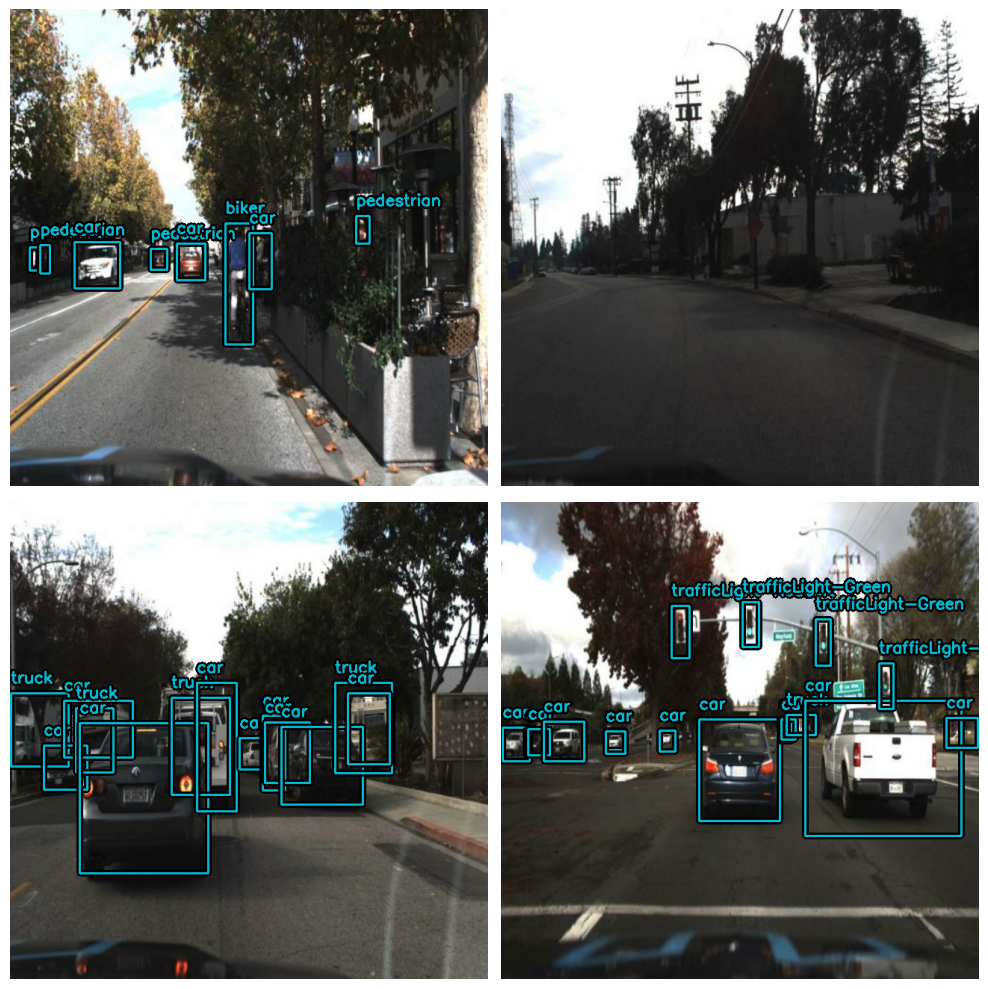

In [ ]:
visualize_dataset(
    val_ds, bounding_box_format="xywh", value_range=(0, 255), rows=2, cols=2
)

In [ ]:
def dict_to_tuple(inputs):
    return inputs["images"], bounding_box.to_dense(
        inputs["bounding_boxes"], max_boxes=32
    )


train_ds = train_ds.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds = val_ds.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

In [ ]:
# Global clipnorm helps to reduce exploding gradient

base_lr = 0.005
# including a global_clipnorm is extremely important in object detection tasks
optimizer = tf.keras.optimizers.SGD(
    learning_rate=base_lr, momentum=0.9, global_clipnorm=10.0
)

In [ ]:
# Creates a "RetinaNet" from ResNet50 backbone

model = keras_cv.models.RetinaNet.from_preset(
    "resnet50_imagenet",
    num_classes=len(class_mapping),
    bounding_box_format="xywh",
)

94657128/94657128 [==============================] - 3s 0us/step


In [ ]:
model.compile(
    classification_loss="focal",
    box_loss="smoothl1",
    optimizer=optimizer,
)

In [ ]:
# Remove take(20) for full training (takes very long!)
model.fit(
    train_ds.take(20),
    validation_data=val_ds.take(20),
    epochs=10,
)

Epoch 1/10
20/20 [==============================] - 682s 34s/step - loss: 1.4748 - box_loss: 0.6340 - classification_loss: 0.8408 - percent_boxes_matched_with_anchor: 0.8012 - val_loss: 1.3639 - val_box_loss: 0.6396 - val_classification_loss: 0.7243 - val_percent_boxes_matched_with_anchor: 0.8242
Epoch 2/10
20/20 [==============================] - 651s 33s/step - loss: 1.4156 - box_loss: 0.6170 - classification_loss: 0.7987 - percent_boxes_matched_with_anchor: 0.8055 - val_loss: 1.2122 - val_box_loss: 0.6260 - val_classification_loss: 0.5862 - val_percent_boxes_matched_with_anchor: 0.8203
Epoch 3/10
20/20 [==============================] - 663s 33s/step - loss: 1.1954 - box_loss: 0.5939 - classification_loss: 0.6016 - percent_boxes_matched_with_anchor: 0.8059 - val_loss: 1.3009 - val_box_loss: 0.6165 - val_classification_loss: 0.6844 - val_percent_boxes_matched_with_anchor: 0.8215
Epoch 4/10
20/20 [==============================] - 639s 32s/step - loss: 1.0488 - box_loss: 0.5725 - clas

In [ ]:
# Let's create a simple function to plot our inferences
def visualize_detections(model, dataset, bounding_box_format):
    images, y_true = next(iter(dataset.take(1)))
    y_pred = model.predict(images)
    y_pred = bounding_box.to_ragged(y_pred)
    visualization.plot_bounding_box_gallery(
        images,
        value_range=(0, 255),
        bounding_box_format=bounding_box_format,
        y_true=y_true,
        y_pred=y_pred,
        scale=4,
        rows=4,
        cols=2,
        show=True,
        font_scale=0.7,
        class_mapping=class_mapping,
    )

In [ ]:
# Set IoU and confidence threshold
model.prediction_decoder = keras_cv.layers.MultiClassNonMaxSuppression(
    bounding_box_format="xywh",
    from_logits=True,
    iou_threshold=0.5,
    confidence_threshold=0.2,
)

In [ ]:
# construct a dataset with larger batches:
visualization_ds = val_ds.unbatch()
visualization_ds = visualization_ds.ragged_batch(16)
visualization_ds = visualization_ds.shuffle(8)

In [33]:
visualize_detections(model, dataset=visualization_ds, bounding_box_format="xywh")

NameError: name 'visualize_detections' is not defined